# MMLogQA Exploratory Data Analysis


## Setup

In [ ]:
pip install torch

ERROR: Could not find a version that satisfies the requirement torch (from versions: none)
ERROR: No matching distribution found for torch
Note: you may need to restart the kernel to use updated packages.


In [6]:
import os, ast, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from PIL import Image
from urllib.parse import urlparse
from transformers import AutoTokenizer
import torch

CLOUD_RAW_PATH   = '../cloud/raw_data'
CLOUD_SPLIT_PATH = '../cloud/split_data'
DEVICE_RAW_PATH  = '../device/raw_data'
DEVICE_SPLIT_PATH = '../device/split_data'

MODEL_NAME = 'bert-base-cased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

ModuleNotFoundError: No module named 'torch'

## Utility Functions

### Token Count Calculation

In [2]:
def text_length(text, add_special_tokens=True):
    if pd.isnull(text) or not isinstance(text, str) or not text.strip(): return 0
    return tokenizer(text, return_tensors='pt', add_special_tokens=add_special_tokens).input_ids.shape[1]

### Image Count Extraction

In [3]:
def count_imgs(x):
    if isinstance(x, str):
        try: x = ast.literal_eval(x)
        except: return 0
    return len(x) if isinstance(x, (list, tuple)) else 0

### Outlier Detection

In [4]:
def find_outliers(df, col):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    low, high = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return (df[col] < low) | (df[col] > high), low, high

### Image Group Analysis

In [5]:
def analyze_by_image_group(df, split_name):
    tmp = df.copy()
    tmp['img_count'] = tmp['img'].apply(count_imgs)
    tmp['img_group'] = tmp['img_count'].apply(lambda x: '1-3' if 1<=x<=3 else ('4-7' if 4<=x<=7 else ('8+' if x>=8 else '0')))
    res = tmp[tmp['img_group'] != '0'].groupby('img_group').agg(
        avg_len=('context_len', 'mean'), count=('context_len', 'count'), long_ctx=('context_len', lambda s: (s > 1000).sum())
    )
    print(f'--- {split_name.upper()} ---')
    print(res)

### Extension & URL Validation

In [6]:
_double_re = re.compile(r'https?://.*https?://', re.I)
_scheme_re = re.compile(r'^https?://', re.I)
_ext_re    = re.compile(r'\.(?:png|jpe?g|gif|svg)(?:\?.*)?$', re.I)

def validate_urls(df, col='img'):
    bad, reasons = set(), []
    for i, cell in enumerate(df[col]):
        try: urls = ast.literal_eval(cell) if isinstance(cell, str) else cell or []
        except: urls = []
        for j, u in enumerate(urls):
            u = str(u).strip()
            if _double_re.search(u): tag = 'double_scheme'
            elif not _scheme_re.match(u): tag = 'missing_scheme'
            elif not _ext_re.search(u): tag = 'bad_extension'
            else: continue
            reasons.append((i, j, u, tag)); bad.add(i); break
    return bad, reasons

---
# Data Loading

### Processing Pipeline

In [7]:
def load_splits(path, prefix):
    data = {}
    for s in ('train', 'test', 'val'):
        df = pd.read_excel(os.path.join(path, f'{prefix}_{s}.xlsx'), usecols=lambda c: 'Unnamed' not in c)
        df['context'] = 'title: ' + df['title'].astype(str) + '\nbody: ' + df['body'].astype(str).str.strip()
        df = df[['context', 'selected_answer', 'images']].rename(columns={'selected_answer':'gt', 'images':'img'})
        df['context_len'] = df['context'].apply(text_length)
        data[s] = df
    return data['train'], data['test'], data['val']

### Load Cloud

In [8]:
c_tr, c_te, c_val = load_splits(CLOUD_SPLIT_PATH, 'cloud')
print(f'Cloud Sizes: {len(c_tr)}, {len(c_te)}, {len(c_val)}')

Token indices sequence length is longer than the specified maximum sequence length for this model (2666 > 512). Running this sequence through the model will result in indexing errors


Cloud Sizes: 4647, 1549, 1614


### Load Device

In [9]:
d_tr, d_te, d_val = load_splits(DEVICE_SPLIT_PATH, 'device')
print(f'Device Sizes: {len(d_tr)}, {len(d_te)}, {len(d_val)}')

Device Sizes: 2928, 977, 976


---
# Cloud EDA

### Token Statistics

In [10]:
for n, d in [('train', c_tr), ('test', c_te), ('val', c_val)]: print(f'\n{n.upper()}:\n{d["context_len"].describe()}')


TRAIN:
count     4647.000000
mean       601.871315
std        947.953274
min         20.000000
25%        191.000000
50%        336.000000
75%        670.500000
max      17353.000000
Name: context_len, dtype: float64

TEST:
count     1549.000000
mean       423.996772
std        681.020552
min         37.000000
25%        133.000000
50%        235.000000
75%        433.000000
max      11068.000000
Name: context_len, dtype: float64

VAL:
count     1614.000000
mean       581.622057
std        804.463171
min         49.000000
25%        182.000000
50%        330.500000
75%        650.750000
max      10063.000000
Name: context_len, dtype: float64


### Visual Distributions

/var/folders/pd/fm_cbz9j21jfk_8yxf970b_r0000gn/T/ipykernel_2449/3367400570.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([c_tr['context_len'], c_te['context_len'], c_val['context_len']], labels=['train', 'test', 'val'])


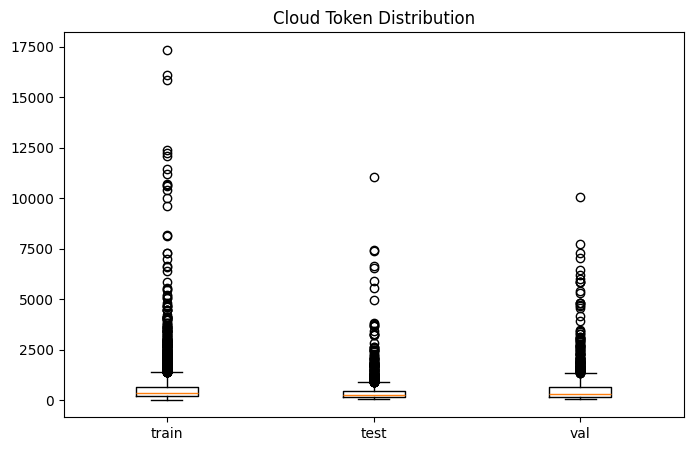

In [11]:
plt.figure(figsize=(8,5))
plt.boxplot([c_tr['context_len'], c_te['context_len'], c_val['context_len']], labels=['train', 'test', 'val'])
plt.title('Cloud Token Distribution')
plt.show()

### Outlier Identification

In [12]:
for n, d in [('train', c_tr), ('test', c_te), ('val', c_val)]:
    m, l, u = find_outliers(d, 'context_len')
    print(f'Cloud {n}: {m.sum()} outliers above {u:.0f}')

Cloud train: 397 outliers above 1390
Cloud test: 157 outliers above 883
Cloud val: 140 outliers above 1354


---
# Device EDA

### Token Statistics

In [13]:
for n, d in [('train', d_tr), ('test', d_te), ('val', d_val)]: print(f'\n{n.upper()}:\n{d["context_len"].describe()}')


TRAIN:
count     2928.000000
mean       634.836066
std       1122.606894
min         48.000000
25%        191.000000
50%        327.500000
75%        620.250000
max      14943.000000
Name: context_len, dtype: float64

TEST:
count      977.000000
mean       626.556807
std       1075.874037
min         45.000000
25%        190.000000
50%        328.000000
75%        631.000000
max      13605.000000
Name: context_len, dtype: float64

VAL:
count      976.000000
mean       630.408811
std       1063.824507
min         50.000000
25%        189.750000
50%        320.000000
75%        627.000000
max      11623.000000
Name: context_len, dtype: float64


### Visual Distributions

/var/folders/pd/fm_cbz9j21jfk_8yxf970b_r0000gn/T/ipykernel_2449/1377223864.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([d_tr['context_len'], d_te['context_len'], d_val['context_len']], labels=['train', 'test', 'val'])


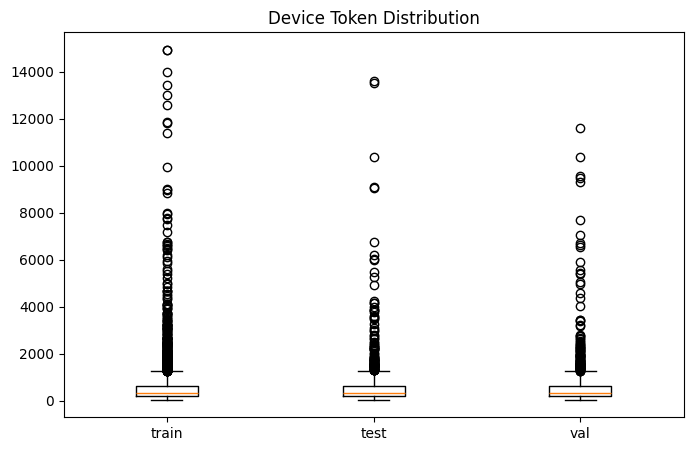

In [14]:
plt.figure(figsize=(8,5))
plt.boxplot([d_tr['context_len'], d_te['context_len'], d_val['context_len']], labels=['train', 'test', 'val'])
plt.title('Device Token Distribution')
plt.show()

---
# Image Analysis

### Image Count Distribution

In [18]:
'''
for name, splits in [('Cloud', [c_tr, c_te, c_val]), ('Device', [d_tr, d_te, d_val])]:
    print(f'\n{name.upper()}:')
    for d in splits: print(f'  Avg Imgs: {d["img"].apply(count_imgs).mean():.2f}')
'''

'\nfor name, splits in [(\'Cloud\', [c_tr, c_te, c_val]), (\'Device\', [d_tr, d_te, d_val])]:\n    print(f\'\n{name.upper()}:\')\n    for d in splits: print(f\'  Avg Imgs: {d["img"].apply(count_imgs).mean():.2f}\')\n'

### Length by Image Group

In [ ]:
'''
for n, d in [('c_tr', c_tr), ('d_tr', d_tr)]: analyze_by_image_group(d, n)
'''

--- C_TR ---
              avg_len  count  long_ctx
img_group                             
1-3        594.708551   4011       568
4-7        622.069159    535        78
8+         842.417582     91        13
--- D_TR ---
              avg_len  count  long_ctx
img_group                             
1-3        619.743048   2697       359
4-7        874.882979    188        28
8+         538.193548     31         3


### URL Validation

In [ ]:
for n, d in [('Cloud Train', c_tr), ('Device Train', d_tr)]:
    bad, _ = validate_urls(d)
    print(f'{n}: {len(bad)} rows with malformed URLs')